In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("heart_risk.csv")
df

,Age,Cholesterol,BloodPressure,Sugar,MaxHeartRate,Smoking,Risk
0,62,152,121,146,118,1,1
1,68,226,144,141,142,1,1
2,37,299,163,157,184,0,1
3,33,157,104,109,140,1,0
4,34,227,100,113,136,1,0
...,...,...,...,...,...,...,...
95,25,182,134,92,130,0,0
96,38,158,156,140,159,0,0
97,31,234,92,106,95,1,1
98,46,200,139,88,97,1,1


In [3]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            100 non-null    int64
 1   Cholesterol    100 non-null    int64
 2   BloodPressure  100 non-null    int64
 3   Sugar          100 non-null    int64
 4   MaxHeartRate   100 non-null    int64
 5   Smoking        100 non-null    int64
 6   Risk           100 non-null    int64
dtypes: int64(7)
memory usage: 5.6 KB


,Age,Cholesterol,BloodPressure,Sugar,MaxHeartRate,Smoking,Risk
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,43.690000,225.840000,128.730000,114.840000,134.810000,0.540000,0.490000
std,12.421629,42.974204,26.866244,25.695466,29.584221,0.500908,0.502418
min,25.000000,152.000000,80.000000,70.000000,92.000000,0.000000,0.000000
25%,33.000000,192.250000,104.750000,96.000000,106.750000,0.000000,0.000000
50%,43.000000,226.000000,127.000000,111.000000,132.000000,1.000000,0.000000
75%,51.250000,263.250000,151.750000,139.250000,162.500000,1.000000,1.000000
max,68.000000,299.000000,179.000000,159.000000,189.000000,1.000000,1.000000


In [4]:
df.isnull().sum()

Age              0
Cholesterol      0
BloodPressure    0
Sugar            0
MaxHeartRate     0
Smoking          0
Risk             0
dtype: int64

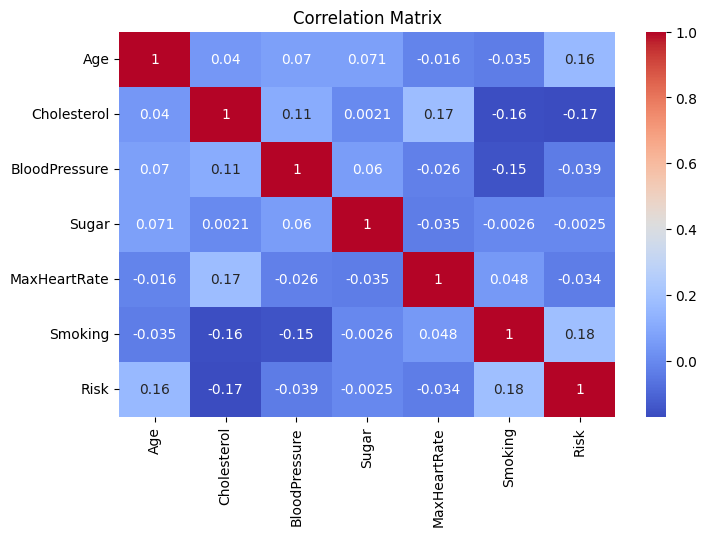

In [5]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [6]:

X = df[['Age','Cholesterol','BloodPressure','Sugar','MaxHeartRate','Smoking']]
y = df['Risk']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 0 1 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

sample = [[45, 210, 130, 120, 150, 1]]


Model Accuracy: 0.55


In [11]:
prediction = model.predict(sample)

if prediction[0] == 1:
    print("High Heart Risk")
else:
    print("Low Heart Risk")

High Heart Risk


C:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
